
Running all cases
datetime_2022 = 2022-09-25 08:39:00
datetime_2023 = 2023-09-23 23:25:00
datetime_2024 = 2024-10-08 02:07:00
delta_t_days_2022_2023 = 363.615
delta_t_days_2023_2024 = 380.113


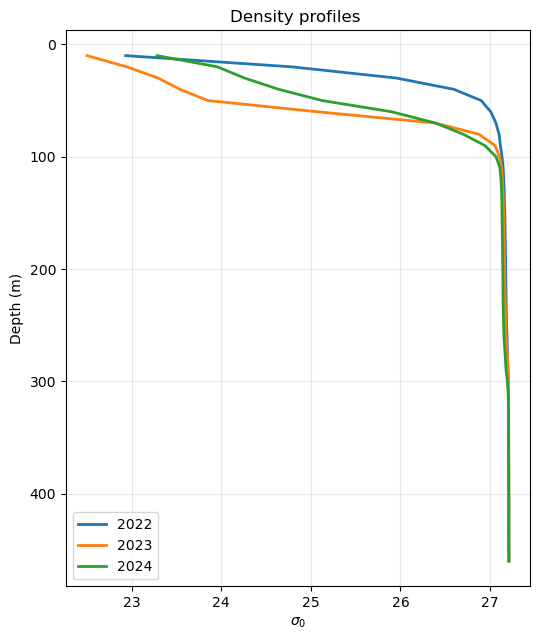

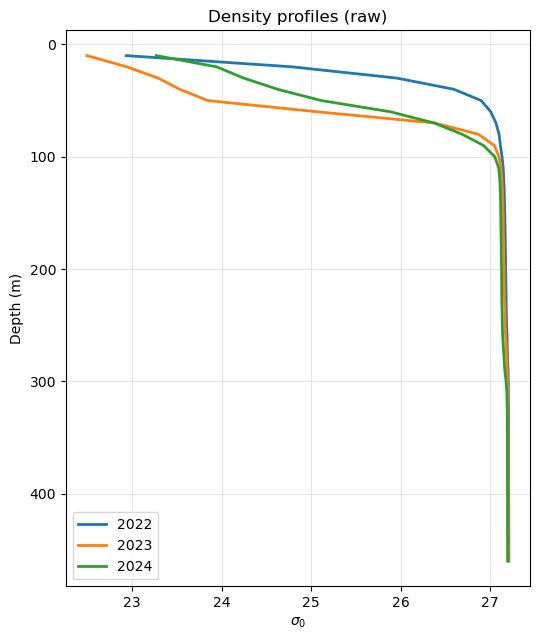

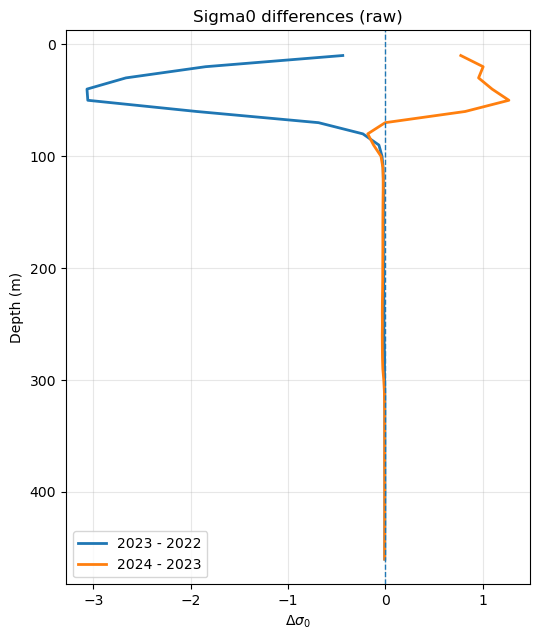

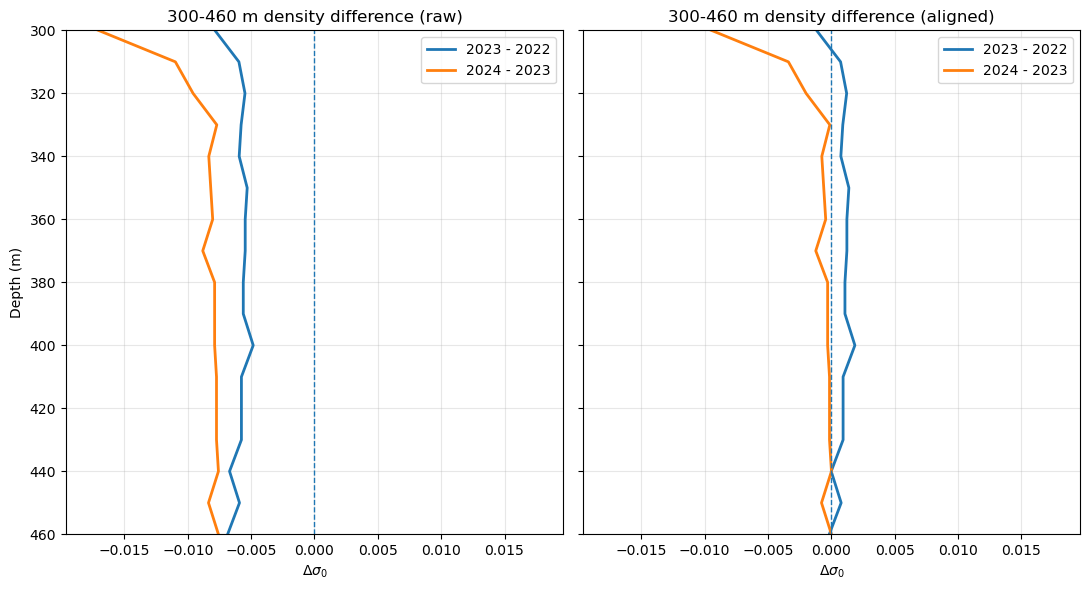

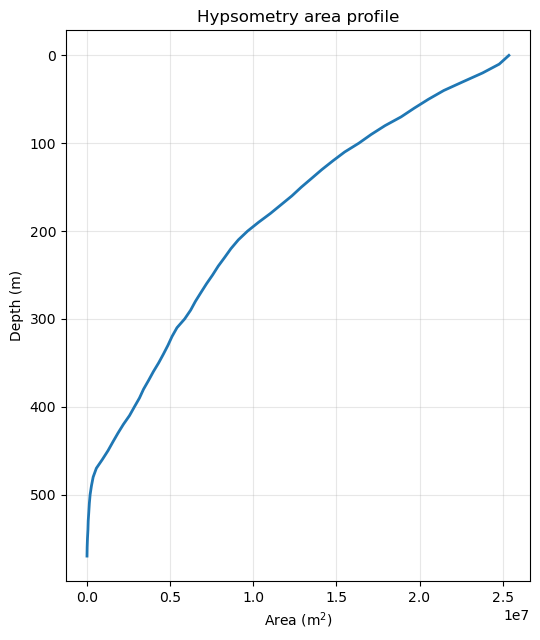

C:\Users\quzho2904\AppData\Local\Temp\ipykernel_25500\3545917910.py:233: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_term = np.trapz(integrand[valid], z_int[valid])
C:\Users\quzho2904\AppData\Local\Temp\ipykernel_25500\3545917910.py:303: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_term = np.trapz(integrand[valid], z_int[valid])



===== aligned result: 2022 - 2023 =====
 u_depth_input  u_depth_actual          A_u  drho_dz_u  integral_term          k_u
           180           180.0 1.103156e+07   0.000197      -0.270908 1.249353e-04
           190           190.0 1.032265e+07   0.000231      -0.225640 9.451971e-05
           200           200.0 9.663060e+06   0.000205      -0.186293 9.389130e-05
           210           210.0 9.106780e+06   0.000194      -0.150786 8.555585e-05
           220           220.0 8.660759e+06   0.000271      -0.116647 4.974307e-05
           230           230.0 8.282797e+06   0.000349      -0.086863 3.004148e-05
           240           240.0 7.893084e+06   0.000297      -0.062474 2.665960e-05
           250           250.0 7.557366e+06   0.000326      -0.040299 1.636775e-05
           260           260.0 7.191126e+06   0.000602      -0.017513 4.046664e-06
           270           270.0 6.855438e+06   0.000718      -0.000668 1.357347e-07
           280           280.0 6.524442e+06   

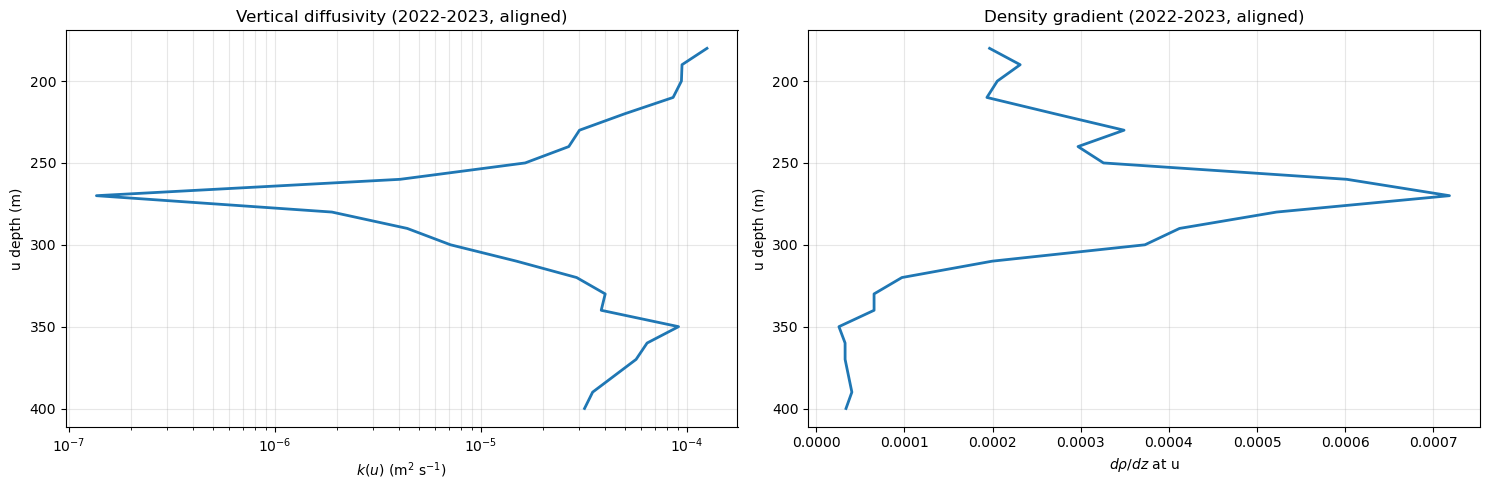

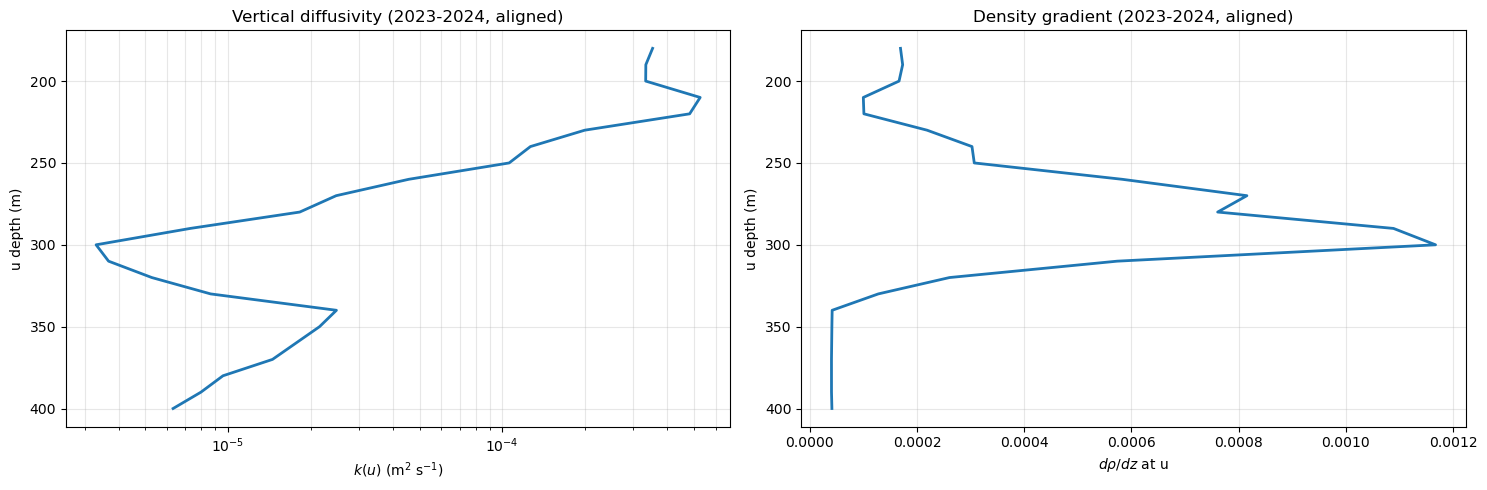

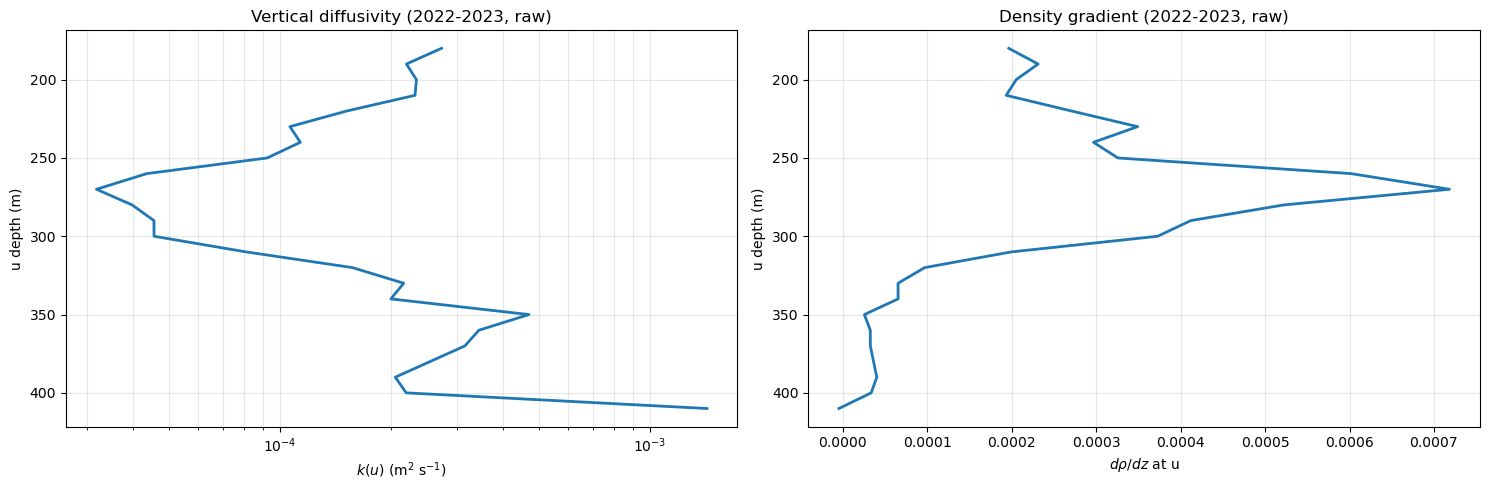

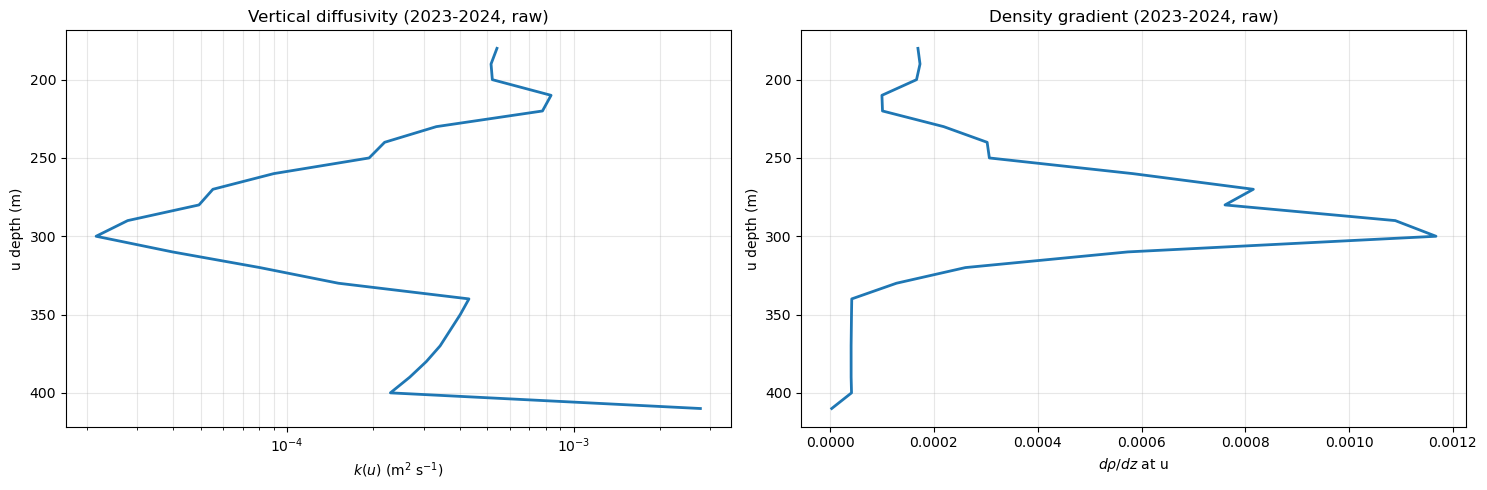

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. Load hypsometry
# =========================================================
def load_hypsometry_csv(hyp_csv):
    df = pd.read_csv(hyp_csv)
    df.columns = df.columns.str.strip()

    required_cols = ["depth_m", "area_m2"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Hypsometry file missing column: {col}")

    z_hyp = df["depth_m"].to_numpy(dtype=float)
    area_z = df["area_m2"].to_numpy(dtype=float)

    volume_z = None
    if "volume_m3" in df.columns:
        volume_z = df["volume_m3"].to_numpy(dtype=float)

    idx = np.argsort(z_hyp)
    z_hyp = z_hyp[idx]
    area_z = area_z[idx]
    if volume_z is not None:
        volume_z = volume_z[idx]

    return z_hyp, area_z, volume_z, df


# =========================================================
# 2. Load all sigma0 data from one CSV
#    This function assumes the aligned CSV also contains raw columns.
# =========================================================
def load_sigma_all_from_csv(sig_csv):
    df = pd.read_csv(sig_csv)
    df.columns = df.columns.str.strip()

    cols = df.columns.tolist()

    # -------------------------
    # mandatory columns
    # -------------------------
    required_base = [
        "depth_m",
        "sigma0_2022_aligned",
        "sigma0_2023_aligned",
        "sigma0_2024_aligned",
        "sigma0_diff_2023_minus_2022_raw",
        "sigma0_diff_2024_minus_2023_raw",
        "datetime_2022",
        "datetime_2023",
        "datetime_2024"
    ]

    missing_base = [c for c in required_base if c not in cols]
    if missing_base:
        raise ValueError(
            "The CSV file is missing required columns:\n" + "\n".join(missing_base)
        )

    # -------------------------
    # raw profile columns
    # try several common naming styles
    # -------------------------
    raw_candidates = [
        ("sigma0_2022", "sigma0_2023", "sigma0_2024"),
        ("sigma0_2022_raw", "sigma0_2023_raw", "sigma0_2024_raw"),
    ]

    raw_cols = None
    for cand in raw_candidates:
        if all(c in cols for c in cand):
            raw_cols = cand
            break

    if raw_cols is None:
        raise ValueError(
            "Could not find raw sigma0 profile columns.\n"
            "Expected one of these sets:\n"
            "1) sigma0_2022, sigma0_2023, sigma0_2024\n"
            "2) sigma0_2022_raw, sigma0_2023_raw, sigma0_2024_raw\n"
            f"Current columns are:\n{cols}"
        )

    z_obs = df["depth_m"].to_numpy(dtype=float)

    # aligned profiles
    rho2022_aligned = df["sigma0_2022_aligned"].to_numpy(dtype=float)
    rho2023_aligned = df["sigma0_2023_aligned"].to_numpy(dtype=float)
    rho2024_aligned = df["sigma0_2024_aligned"].to_numpy(dtype=float)

    # raw profiles
    rho2022_raw = df[raw_cols[0]].to_numpy(dtype=float)
    rho2023_raw = df[raw_cols[1]].to_numpy(dtype=float)
    rho2024_raw = df[raw_cols[2]].to_numpy(dtype=float)

    # raw differences
    drho_2023_minus_2022_raw = df["sigma0_diff_2023_minus_2022_raw"].to_numpy(dtype=float)
    drho_2024_minus_2023_raw = df["sigma0_diff_2024_minus_2023_raw"].to_numpy(dtype=float)

    # datetimes
    dt2022_series = df["datetime_2022"].dropna()
    dt2023_series = df["datetime_2023"].dropna()
    dt2024_series = df["datetime_2024"].dropna()

    if len(dt2022_series) == 0 or len(dt2023_series) == 0 or len(dt2024_series) == 0:
        raise ValueError("Datetime columns exist, but one or more are empty.")

    dt_2022 = pd.to_datetime(dt2022_series.iloc[0])
    dt_2023 = pd.to_datetime(dt2023_series.iloc[0])
    dt_2024 = pd.to_datetime(dt2024_series.iloc[0])

    return (
        z_obs,
        rho2022_aligned,
        rho2023_aligned,
        rho2024_aligned,
        rho2022_raw,
        rho2023_raw,
        rho2024_raw,
        drho_2023_minus_2022_raw,
        drho_2024_minus_2023_raw,
        dt_2022,
        dt_2023,
        dt_2024,
        df
    )


# =========================================================
# 3. Interpolate profile onto hypsometry grid
# =========================================================
def interp_profile_to_grid(z_obs, var_obs, z_grid):
    z_obs = np.asarray(z_obs, dtype=float)
    var_obs = np.asarray(var_obs, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)

    mask = np.isfinite(z_obs) & np.isfinite(var_obs)
    z_obs = z_obs[mask]
    var_obs = var_obs[mask]

    if len(z_obs) < 2:
        raise ValueError("Not enough valid observations for interpolation.")

    idx = np.argsort(z_obs)
    z_obs = z_obs[idx]
    var_obs = var_obs[idx]

    var_grid = np.interp(z_grid, z_obs, var_obs, left=np.nan, right=np.nan)

    zmin = np.nanmin(z_obs)
    zmax = np.nanmax(z_obs)
    var_grid[(z_grid < zmin) | (z_grid > zmax)] = np.nan

    return var_grid


# =========================================================
# 4. Simple smoothing
# =========================================================
def moving_average_nan(x, window=1):
    x = np.asarray(x, dtype=float)

    if window <= 1:
        return x.copy()

    y = np.full_like(x, np.nan)
    half = window // 2

    for i in range(len(x)):
        i0 = max(0, i - half)
        i1 = min(len(x), i + half + 1)
        seg = x[i0:i1]
        if np.isfinite(seg).sum() > 0:
            y[i] = np.nanmean(seg)

    return y


# =========================================================
# 5. Compute k from two full profiles
# =========================================================
def compute_vertical_diffusivity_single_u(
    z_grid,
    area_z,
    rho_t1,
    rho_t2,
    delta_t_days,
    u_depth,
    smooth_window=1,
    use_abs_value=True
):
    z_grid = np.asarray(z_grid, dtype=float)
    area_z = np.asarray(area_z, dtype=float)
    rho_t1 = np.asarray(rho_t1, dtype=float)
    rho_t2 = np.asarray(rho_t2, dtype=float)

    delta_t_sec = delta_t_days * 24 * 3600.0

    rho1_s = moving_average_nan(rho_t1, window=smooth_window)
    rho2_s = moving_average_nan(rho_t2, window=smooth_window)

    drho_dt = (rho2_s - rho1_s) / delta_t_sec

    u_index = np.argmin(np.abs(z_grid - u_depth))
    u_depth_actual = z_grid[u_index]

    drho_dz = np.gradient(rho2_s, z_grid)
    drho_dz_u = drho_dz[u_index]

    A_u = area_z[u_index]

    mask_int = z_grid >= u_depth_actual
    z_int = z_grid[mask_int]
    integrand = area_z[mask_int] * drho_dt[mask_int]

    valid = np.isfinite(z_int) & np.isfinite(integrand)

    if valid.sum() < 2:
        return {
            "u_depth_input": u_depth,
            "u_depth_actual": u_depth_actual,
            "A_u": A_u,
            "drho_dz_u": np.nan,
            "integral_term": np.nan,
            "k_u": np.nan
        }

    integral_term = np.trapz(integrand[valid], z_int[valid])

    denominator = A_u * drho_dz_u

    if (not np.isfinite(denominator)) or (denominator == 0):
        k_u = np.nan
    else:
        k_u = integral_term / denominator
        if use_abs_value:
            k_u = np.abs(k_u)

    return {
        "u_depth_input": u_depth,
        "u_depth_actual": u_depth_actual,
        "A_u": A_u,
        "drho_dz_u": drho_dz_u,
        "integral_term": integral_term,
        "k_u": k_u
    }


# =========================================================
# 6. Compute k from raw diff + raw reference profile
# =========================================================
def compute_vertical_diffusivity_from_diff_single_u(
    z_grid,
    area_z,
    rho_ref,
    drho,
    delta_t_days,
    u_depth,
    smooth_window=1,
    use_abs_value=True
):
    z_grid = np.asarray(z_grid, dtype=float)
    area_z = np.asarray(area_z, dtype=float)
    rho_ref = np.asarray(rho_ref, dtype=float)
    drho = np.asarray(drho, dtype=float)

    delta_t_sec = delta_t_days * 24 * 3600.0

    rho_ref_s = moving_average_nan(rho_ref, window=smooth_window)
    drho_s = moving_average_nan(drho, window=smooth_window)

    drho_dt = drho_s / delta_t_sec

    u_index = np.argmin(np.abs(z_grid - u_depth))
    u_depth_actual = z_grid[u_index]

    drho_dz = np.gradient(rho_ref_s, z_grid)
    drho_dz_u = drho_dz[u_index]

    A_u = area_z[u_index]

    mask_int = z_grid >= u_depth_actual
    z_int = z_grid[mask_int]
    integrand = area_z[mask_int] * drho_dt[mask_int]

    valid = np.isfinite(z_int) & np.isfinite(integrand)

    if valid.sum() < 2:
        return {
            "u_depth_input": u_depth,
            "u_depth_actual": u_depth_actual,
            "A_u": A_u,
            "drho_dz_u": np.nan,
            "integral_term": np.nan,
            "k_u": np.nan
        }

    integral_term = np.trapz(integrand[valid], z_int[valid])

    denominator = A_u * drho_dz_u

    if (not np.isfinite(denominator)) or (denominator == 0):
        k_u = np.nan
    else:
        k_u = integral_term / denominator
        if use_abs_value:
            k_u = np.abs(k_u)

    return {
        "u_depth_input": u_depth,
        "u_depth_actual": u_depth_actual,
        "A_u": A_u,
        "drho_dz_u": drho_dz_u,
        "integral_term": integral_term,
        "k_u": k_u
    }


# =========================================================
# 7. Scan multiple u depths from two profiles
# =========================================================
def scan_u_depths(
    z_grid,
    area_z,
    rho_t1,
    rho_t2,
    delta_t_days,
    u_depth_list,
    smooth_window=1,
    use_abs_value=True
):
    results = []

    for u in u_depth_list:
        res = compute_vertical_diffusivity_single_u(
            z_grid=z_grid,
            area_z=area_z,
            rho_t1=rho_t1,
            rho_t2=rho_t2,
            delta_t_days=delta_t_days,
            u_depth=u,
            smooth_window=smooth_window,
            use_abs_value=use_abs_value
        )
        results.append(res)

    return pd.DataFrame(results)


# =========================================================
# 8. Scan multiple u depths from raw diff + raw reference
# =========================================================
def scan_u_depths_from_diff(
    z_grid,
    area_z,
    rho_ref,
    drho,
    delta_t_days,
    u_depth_list,
    smooth_window=1,
    use_abs_value=True
):
    results = []

    for u in u_depth_list:
        res = compute_vertical_diffusivity_from_diff_single_u(
            z_grid=z_grid,
            area_z=area_z,
            rho_ref=rho_ref,
            drho=drho,
            delta_t_days=delta_t_days,
            u_depth=u,
            smooth_window=smooth_window,
            use_abs_value=use_abs_value
        )
        results.append(res)

    return pd.DataFrame(results)


# =========================================================
# 9. Plot profiles
# =========================================================
def plot_density_profiles(z_grid, rho2022_grid, rho2023_grid, rho2024_grid, title_suffix="", save_path=None):
    plt.figure(figsize=(5.5, 6.5))
    plt.plot(rho2022_grid, z_grid, label="2022", linewidth=2)
    plt.plot(rho2023_grid, z_grid, label="2023", linewidth=2)
    plt.plot(rho2024_grid, z_grid, label="2024", linewidth=2)

    plt.gca().invert_yaxis()
    plt.xlabel(r"$\sigma_0$")
    plt.ylabel("Depth (m)")
    plt.title(f"Density profiles {title_suffix}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_diff_profiles(z_grid, drho_2023_2022_grid, drho_2024_2023_grid, title_suffix=""):
    plt.figure(figsize=(5.5, 6.5))
    plt.plot(drho_2023_2022_grid, z_grid, label="2023 - 2022", linewidth=2)
    plt.plot(drho_2024_2023_grid, z_grid, label="2024 - 2023", linewidth=2)

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.gca().invert_yaxis()
    plt.xlabel(r"$\Delta \sigma_0$")
    plt.ylabel("Depth (m)")
    plt.title(f"Sigma0 differences {title_suffix}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
# =========================================================
# 9b. Plot 300-400 m density differences and area profile
# =========================================================
def plot_density_diff_300_450m(
    z_grid,
    rho2022_raw_grid,
    rho2023_raw_grid,
    rho2024_raw_grid,
    rho2022_aligned_grid,
    rho2023_aligned_grid,
    rho2024_aligned_grid
):
    z_grid = np.asarray(z_grid, dtype=float)

    # raw differences
    drho_raw_2023_2022 = rho2023_raw_grid - rho2022_raw_grid
    drho_raw_2024_2023 = rho2024_raw_grid - rho2023_raw_grid

    # aligned differences
    drho_aligned_2023_2022 = rho2023_aligned_grid - rho2022_aligned_grid
    drho_aligned_2024_2023 = rho2024_aligned_grid - rho2023_aligned_grid

    # only keep 300-460 m
    mask = (z_grid >= 300) & (z_grid <= 460)

    z_sub = z_grid[mask]
    raw_23_22 = drho_raw_2023_2022[mask]
    raw_24_23 = drho_raw_2024_2023[mask]
    aligned_23_22 = drho_aligned_2023_2022[mask]
    aligned_24_23 = drho_aligned_2024_2023[mask]

    # automatically choose cautious x-limits
    all_vals = np.concatenate([
        raw_23_22[np.isfinite(raw_23_22)],
        raw_24_23[np.isfinite(raw_24_23)],
        aligned_23_22[np.isfinite(aligned_23_22)],
        aligned_24_23[np.isfinite(aligned_24_23)]
    ])

    if len(all_vals) > 0:
        vmax = np.nanmax(np.abs(all_vals))
        xlim = max(0.005, vmax * 1.15)
    else:
        xlim = 0.01

    fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)

    # -------------------------
    # left: raw
    # -------------------------
    axes[0].plot(raw_23_22, z_sub, linewidth=2, label="2023 - 2022")
    axes[0].plot(raw_24_23, z_sub, linewidth=2, label="2024 - 2023")
    axes[0].axvline(0, linestyle="--", linewidth=1)
    axes[0].invert_yaxis()
    axes[0].set_ylim(460, 300)
    axes[0].set_xlim(-xlim, xlim)
    axes[0].set_xlabel(r"$\Delta \sigma_0$")
    axes[0].set_ylabel("Depth (m)")
    axes[0].set_title("300-460 m density difference (raw)")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # -------------------------
    # right: aligned
    # -------------------------
    axes[1].plot(aligned_23_22, z_sub, linewidth=2, label="2023 - 2022")
    axes[1].plot(aligned_24_23, z_sub, linewidth=2, label="2024 - 2023")
    axes[1].axvline(0, linestyle="--", linewidth=1)
    axes[1].invert_yaxis()
    axes[1].set_ylim(460, 300)
    axes[1].set_xlim(-xlim, xlim)
    axes[1].set_xlabel(r"$\Delta \sigma_0$")
    axes[1].set_title("300-460 m density difference (aligned)")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_area_profile(z_grid, area_z):
    z_grid = np.asarray(z_grid, dtype=float)
    area_z = np.asarray(area_z, dtype=float)

    plt.figure(figsize=(5.5, 6.5))
    plt.plot(area_z, z_grid, linewidth=2)
    plt.gca().invert_yaxis()
    plt.xlabel(r"Area (m$^2$)")
    plt.ylabel("Depth (m)")
    plt.title("Hypsometry area profile")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# 10. Plot scan results
# =========================================================
def plot_scan_results(df_scan, title_suffix="", save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    mask_k = np.isfinite(df_scan["k_u"]) & (df_scan["k_u"] > 0)

    axes[0].plot(
        df_scan.loc[mask_k, "k_u"],
        df_scan.loc[mask_k, "u_depth_actual"],
        "-",
        linewidth=2
    )
    axes[0].set_xscale("log")
    axes[0].invert_yaxis()
    axes[0].set_xlabel(r"$k(u)$ (m$^2$ s$^{-1}$)")
    axes[0].set_ylabel("u depth (m)")
    axes[0].set_title(f"Vertical diffusivity {title_suffix}")
    axes[0].grid(True, which="both", alpha=0.3)

    axes[1].plot(
        df_scan["drho_dz_u"],
        df_scan["u_depth_actual"],
        "-",
        linewidth=2
    )
    axes[1].invert_yaxis()
    axes[1].set_xlabel(r"$d\rho/dz$ at u")
    axes[1].set_ylabel("u depth (m)")
    axes[1].set_title(f"Density gradient {title_suffix}")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# =========================================================
# 11. Main workflow
# =========================================================
def run_all_cases(
    hyp_csv,
    sig_csv,
    save_csv_aligned_2022_2023,
    save_csv_aligned_2023_2024,
    save_csv_raw_2022_2023,
    save_csv_raw_2023_2024,
    smooth_window=1,
    u_depth_list=np.arange(180, 441, 10),
    remove_depth_2022_2023=380,
    remove_depth_2023_2024=360
):
    print("\n" + "=" * 72)
    print("Running all cases")
    print("=" * 72)

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------
    z_hyp, area_z, volume_z, df_hyp = load_hypsometry_csv(hyp_csv)

    (
        z_obs,
        rho2022_aligned_obs,
        rho2023_aligned_obs,
        rho2024_aligned_obs,
        rho2022_raw_obs,
        rho2023_raw_obs,
        rho2024_raw_obs,
        drho_2023_2022_raw_obs,
        drho_2024_2023_raw_obs,
        dt_2022,
        dt_2023,
        dt_2024,
        df_sig
    ) = load_sigma_all_from_csv(sig_csv)

    # -----------------------------------------------------
    # Compute delta t
    # -----------------------------------------------------
    delta_t_days_2022_2023 = (dt_2023 - dt_2022).total_seconds() / 86400.0
    delta_t_days_2023_2024 = (dt_2024 - dt_2023).total_seconds() / 86400.0

    if delta_t_days_2022_2023 <= 0 or delta_t_days_2023_2024 <= 0:
        raise ValueError("Computed delta_t_days is non-positive. Check datetime order in the file.")

    print(f"datetime_2022 = {dt_2022}")
    print(f"datetime_2023 = {dt_2023}")
    print(f"datetime_2024 = {dt_2024}")
    print(f"delta_t_days_2022_2023 = {delta_t_days_2022_2023:.3f}")
    print(f"delta_t_days_2023_2024 = {delta_t_days_2023_2024:.3f}")

    # -----------------------------------------------------
    # Interpolate all profiles onto hypsometry grid
    # -----------------------------------------------------
    rho2022_aligned_grid = interp_profile_to_grid(z_obs, rho2022_aligned_obs, z_hyp)
    rho2023_aligned_grid = interp_profile_to_grid(z_obs, rho2023_aligned_obs, z_hyp)
    rho2024_aligned_grid = interp_profile_to_grid(z_obs, rho2024_aligned_obs, z_hyp)

    rho2022_raw_grid = interp_profile_to_grid(z_obs, rho2022_raw_obs, z_hyp)
    rho2023_raw_grid = interp_profile_to_grid(z_obs, rho2023_raw_obs, z_hyp)
    rho2024_raw_grid = interp_profile_to_grid(z_obs, rho2024_raw_obs, z_hyp)

    drho_2023_2022_raw_grid = interp_profile_to_grid(z_obs, drho_2023_2022_raw_obs, z_hyp)
    drho_2024_2023_raw_grid = interp_profile_to_grid(z_obs, drho_2024_2023_raw_obs, z_hyp)

    # -----------------------------------------------------
    # Plot profile figures
    # -----------------------------------------------------
    plot_density_profiles(
        z_hyp,
        rho2022_aligned_grid,
        rho2023_aligned_grid,
        rho2024_aligned_grid,
        title_suffix="",
        save_path=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\figures\density_profiles_aligned.png"
    )

    plot_density_profiles(
        z_hyp,
        rho2022_raw_grid,
        rho2023_raw_grid,
        rho2024_raw_grid,
        title_suffix="(raw)"
    )

    plot_diff_profiles(
        z_hyp,
        drho_2023_2022_raw_grid,
        drho_2024_2023_raw_grid,
        title_suffix="(raw)"
    )

    plot_density_diff_300_450m(
        z_hyp,
        rho2022_raw_grid,
        rho2023_raw_grid,
        rho2024_raw_grid,
        rho2022_aligned_grid,
        rho2023_aligned_grid,
        rho2024_aligned_grid
    )

    plot_area_profile(z_hyp, area_z)

    # -----------------------------------------------------
    # Case A: aligned result
    # -----------------------------------------------------
    df_scan_aligned_2022_2023 = scan_u_depths(
        z_grid=z_hyp,
        area_z=area_z,
        rho_t1=rho2022_aligned_grid,
        rho_t2=rho2023_aligned_grid,
        delta_t_days=delta_t_days_2022_2023,
        u_depth_list=u_depth_list,
        smooth_window=smooth_window,
        use_abs_value=True
    )

    df_scan_aligned_2023_2024 = scan_u_depths(
        z_grid=z_hyp,
        area_z=area_z,
        rho_t1=rho2023_aligned_grid,
        rho_t2=rho2024_aligned_grid,
        delta_t_days=delta_t_days_2023_2024,
        u_depth_list=u_depth_list,
        smooth_window=smooth_window,
        use_abs_value=True
    )

    # -----------------------------------------------------
    # Case B: raw result
    # change term from raw diff
    # gradient term from raw reference profile
    # -----------------------------------------------------
    df_scan_raw_2022_2023 = scan_u_depths_from_diff(
        z_grid=z_hyp,
        area_z=area_z,
        rho_ref=rho2023_raw_grid,
        drho=drho_2023_2022_raw_grid,
        delta_t_days=delta_t_days_2022_2023,
        u_depth_list=u_depth_list,
        smooth_window=smooth_window,
        use_abs_value=True
    )

    df_scan_raw_2023_2024 = scan_u_depths_from_diff(
        z_grid=z_hyp,
        area_z=area_z,
        rho_ref=rho2024_raw_grid,
        drho=drho_2024_2023_raw_grid,
        delta_t_days=delta_t_days_2023_2024,
        u_depth_list=u_depth_list,
        smooth_window=smooth_window,
        use_abs_value=True
    )

    # -----------------------------------------------------
    # Remove selected depths
    # -----------------------------------------------------
    if remove_depth_2022_2023 is not None:
        df_scan_aligned_2022_2023 = df_scan_aligned_2022_2023[
            ~np.isclose(df_scan_aligned_2022_2023["u_depth_actual"], remove_depth_2022_2023)
        ].reset_index(drop=True)

        df_scan_raw_2022_2023 = df_scan_raw_2022_2023[
            ~np.isclose(df_scan_raw_2022_2023["u_depth_actual"], remove_depth_2022_2023)
        ].reset_index(drop=True)

    if remove_depth_2023_2024 is not None:
        df_scan_aligned_2023_2024 = df_scan_aligned_2023_2024[
            ~np.isclose(df_scan_aligned_2023_2024["u_depth_actual"], remove_depth_2023_2024)
        ].reset_index(drop=True)

        df_scan_raw_2023_2024 = df_scan_raw_2023_2024[
            ~np.isclose(df_scan_raw_2023_2024["u_depth_actual"], remove_depth_2023_2024)
        ].reset_index(drop=True)
        # -----------------------------------------------------
        # Keep only output range: 180-410 m
        # -----------------------------------------------------
        df_scan_aligned_2022_2023 = df_scan_aligned_2022_2023[
            (df_scan_aligned_2022_2023["u_depth_actual"] >= 180) &
            (df_scan_aligned_2022_2023["u_depth_actual"] <= 400)
        ].reset_index(drop=True)

        df_scan_aligned_2023_2024 = df_scan_aligned_2023_2024[
            (df_scan_aligned_2023_2024["u_depth_actual"] >= 180) &
            (df_scan_aligned_2023_2024["u_depth_actual"] <= 400)
        ].reset_index(drop=True)

        df_scan_raw_2022_2023 = df_scan_raw_2022_2023[
            (df_scan_raw_2022_2023["u_depth_actual"] >= 180) &
            (df_scan_raw_2022_2023["u_depth_actual"] <= 410)
        ].reset_index(drop=True)

        df_scan_raw_2023_2024 = df_scan_raw_2023_2024[
            (df_scan_raw_2023_2024["u_depth_actual"] >= 180) &
            (df_scan_raw_2023_2024["u_depth_actual"] <= 410)
        ].reset_index(drop=True)
    # -----------------------------------------------------
    # Print results
    # -----------------------------------------------------
    print("\n===== aligned result: 2022 - 2023 =====")
    print(df_scan_aligned_2022_2023.to_string(index=False))

    print("\n===== aligned result: 2023 - 2024 =====")
    print(df_scan_aligned_2023_2024.to_string(index=False))

    print("\n===== raw result: 2022 - 2023 =====")
    print(df_scan_raw_2022_2023.to_string(index=False))

    print("\n===== raw result: 2023 - 2024 =====")
    print(df_scan_raw_2023_2024.to_string(index=False))

    # -----------------------------------------------------
    # Save results
    # -----------------------------------------------------
    df_scan_aligned_2022_2023.to_csv(save_csv_aligned_2022_2023, index=False, encoding="utf-8-sig")
    df_scan_aligned_2023_2024.to_csv(save_csv_aligned_2023_2024, index=False, encoding="utf-8-sig")
    df_scan_raw_2022_2023.to_csv(save_csv_raw_2022_2023, index=False, encoding="utf-8-sig")
    df_scan_raw_2023_2024.to_csv(save_csv_raw_2023_2024, index=False, encoding="utf-8-sig")

    print(f"\nSaved aligned 2022->2023 results to:\n{save_csv_aligned_2022_2023}")
    print(f"Saved aligned 2023->2024 results to:\n{save_csv_aligned_2023_2024}")
    print(f"Saved raw 2022->2023 results to:\n{save_csv_raw_2022_2023}")
    print(f"Saved raw 2023->2024 results to:\n{save_csv_raw_2023_2024}")

    # -----------------------------------------------------
    # Plot scan results
    # -----------------------------------------------------
    plot_scan_results(df_scan_aligned_2022_2023, title_suffix="(2022-2023, aligned)", save_path=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\figures\k_scan_2022_2023_aligned.png")
    plot_scan_results(df_scan_aligned_2023_2024, title_suffix="(2023-2024, aligned)", save_path=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\figures\k_scan_2023_2024_aligned.png")
    plot_scan_results(df_scan_raw_2022_2023, title_suffix="(2022-2023, raw)", save_path=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\figures\k_scan_2022_2023_raw.png")
    plot_scan_results(df_scan_raw_2023_2024, title_suffix="(2023-2024, raw)", save_path=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\figures\k_scan_2023_2024_raw.png")

    return (
        df_scan_aligned_2022_2023,
        df_scan_aligned_2023_2024,
        df_scan_raw_2022_2023,
        df_scan_raw_2023_2024
    )


# =========================================================
# 12. Main program
# =========================================================
if __name__ == "__main__":

    hyp_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\hypsometry_dz10m_lonLE5.30.csv"

    sig_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station367_2022_vs_station446_2023_vs_station519_2024_aligned.csv"

    smooth_window = 1
    u_depth_list = np.arange(170, 421, 10)

    (
        df_scan_aligned_2022_2023,
        df_scan_aligned_2023_2024,
        df_scan_raw_2022_2023,
        df_scan_raw_2023_2024
    ) = run_all_cases(
        hyp_csv=hyp_csv,
        sig_csv=sig_csv,
        save_csv_aligned_2022_2023=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_scan_u_station367_2022_vs_station446_2023_aligned.csv",
        save_csv_aligned_2023_2024=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_scan_u_station446_2023_vs_station519_2024_aligned.csv",
        save_csv_raw_2022_2023=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_scan_u_station367_2022_vs_station446_2023_raw.csv",
        save_csv_raw_2023_2024=r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_scan_u_station446_2023_vs_station519_2024_raw.csv",
        smooth_window=smooth_window,
        u_depth_list=u_depth_list,
        remove_depth_2022_2023=380,
        remove_depth_2023_2024=360
    )